=== Segment Boundary Reference ===
Normal Train Shape 99% threshold : 0.1895
Normal Holdout cycles             : 145
Edge margin median                : 8.0 samples

=== Boundary Distance Dependency ===
Edge margin ↔ Shape RMSE : rho=0.1086, p=0.1935
Edge margin ↔ Duration   : rho=-0.0441, p=0.5985

=== Boundary Sensitivity ===
 boundary_samples  boundary_sec_approx  near_n  inner_n  near_rmse_median  inner_rmse_median  near_rmse_q95  inner_rmse_q95  near_fpr  inner_fpr  rmse_p  duration_p
                1                  0.1       0      145               NaN             0.0737            NaN          0.1671       NaN     0.0069     NaN         NaN
                3                  0.3       9      136            0.0618             0.0758         0.1527          0.1650       0.0     0.0074  0.2331      0.6656
                5                  0.5      38      107            0.0737             0.0754         0.1685          0.1626       0.0     0.0093  0.5188      0.4955

=== 3-Sam

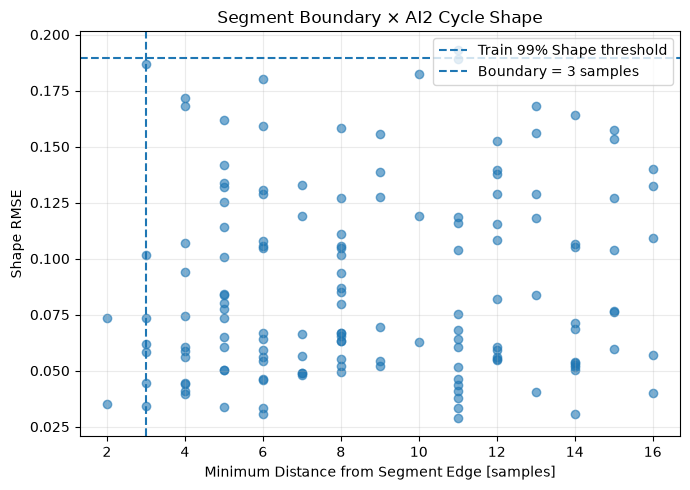

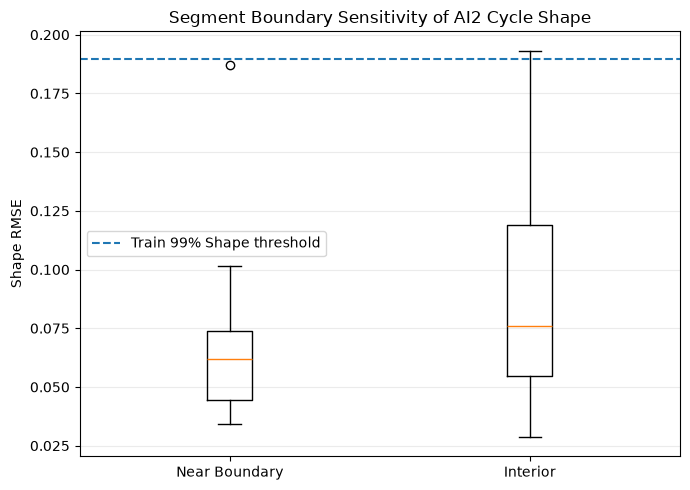


Saved to: c:\Users\astra\Desktop\K_eng\KAMP\05_EDA\05_Physics_Informed\07_Boundary_Sensitivity_results


In [1]:
# Gap으로 생성된 segment 경계가 AI2 Cycle Shape 결과를 왜곡하는지 검증한다.
# Normal Holdout cycle의 segment-edge 거리와 Shape RMSE / Duration / FPR 관계를 비교한다.
# 1·3·5 sample 경계 기준을 모두 검사해 특정 boundary 정의에 의존하는지도 확인한다.
# 경계 효과가 작으면 Gap segmentation이 핵심 Cycle Shape 결과의 artifact가 아님을 지지한다.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import spearmanr, mannwhitneyu

MIN_SEG_ROWS, MIN_PEAK_DIST, TH_Q = 30, 12, .99
BOUNDARY_TESTS = [1, 3, 5]


# ------------------------------------------------------------
# 1. 경로 / 기존 Shape 결과
# ------------------------------------------------------------
def find_root():
    starts = [Path.cwd()]
    try: starts.append(Path(__file__).resolve().parent)
    except NameError: pass
    for start in starts:
        for p in [start, *start.parents]:
            if (p / "data/processed/preprocessed_data.csv").exists(): return p
    raise FileNotFoundError("프로젝트 root를 찾지 못했습니다.")

ROOT = find_root()
DATA_PATH = ROOT / "data/processed/preprocessed_data.csv"
SHAPE_DIR = ROOT / "KAMP/05_EDA/05_Physics_Informed/03_Current_Shape_results"
OUT = ROOT / "KAMP/05_EDA/05_Physics_Informed/07_Boundary_Sensitivity_results"
OUT.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(DATA_PATH)
train_shape = pd.read_csv(SHAPE_DIR / "normal_train_current_shape.csv")
holdout = pd.read_csv(SHAPE_DIR / "normal_holdout_current_shape.csv")
RMSE_TH = train_shape.Shape_RMSE.quantile(TH_Q)


# ------------------------------------------------------------
# 2. 동일 Cycle detector로 경계거리 복원
# ------------------------------------------------------------
def extract_boundary_meta(df):
    rows = []

    for seg, g in df[df.source == "normal"].groupby("segment_id", sort=False):
        g = g.sort_values("pos_in_seg").reset_index(drop=True)
        if len(g) < MIN_SEG_ROWS: continue

        cur = g.AI2_Current.to_numpy(float)
        sm = pd.Series(cur).rolling(3, center=True, min_periods=1).median().to_numpy()
        prom = max(np.std(sm, ddof=1) * .5, np.finfo(float).eps)
        peaks, _ = find_peaks(sm, distance=MIN_PEAK_DIST, prominence=prom)

        for cid, (s, e) in enumerate(zip(peaks[:-1], peaks[1:]), 1):
            if e - s < MIN_PEAK_DIST: continue

            duration = g.elapsed_sec.iloc[e] - g.elapsed_sec.iloc[s]
            if duration <= 0: continue

            left_margin = s
            right_margin = len(g) - 1 - e

            rows.append({
                "segment_id": seg, "cycle_id": cid, "seg_len": len(g),
                "cycle_start_pos": s, "cycle_end_pos": e,
                "left_margin": left_margin, "right_margin": right_margin,
                "edge_margin": min(left_margin, right_margin)
            })

    return pd.DataFrame(rows)

boundary = extract_boundary_meta(data)
holdout = holdout.merge(boundary, on=["segment_id", "cycle_id"], how="left")
holdout["Shape_Break_Fixed"] = holdout.Shape_RMSE > RMSE_TH

if holdout.edge_margin.isna().any():
    raise ValueError("기존 Shape cycle과 boundary cycle 매칭 실패가 있습니다.")


# ------------------------------------------------------------
# 3. 전체 Boundary dependency
# ------------------------------------------------------------
rho_r, p_r = spearmanr(holdout.edge_margin, holdout.Shape_RMSE)
rho_t, p_t = spearmanr(holdout.edge_margin, holdout.duration_sec)

print("=== Segment Boundary Reference ===")
print(f"Normal Train Shape 99% threshold : {RMSE_TH:.4f}")
print(f"Normal Holdout cycles             : {len(holdout)}")
print(f"Edge margin median                : {holdout.edge_margin.median():.1f} samples")

print("\n=== Boundary Distance Dependency ===")
print(f"Edge margin ↔ Shape RMSE : rho={rho_r:.4f}, p={p_r:.4g}")
print(f"Edge margin ↔ Duration   : rho={rho_t:.4f}, p={p_t:.4g}")


# ------------------------------------------------------------
# 4. 1 / 3 / 5 sample Boundary sensitivity
# ------------------------------------------------------------
rows = []

for margin in BOUNDARY_TESTS:
    near = holdout[holdout.edge_margin <= margin]
    inner = holdout[holdout.edge_margin > margin]

    p_rmse = mannwhitneyu(near.Shape_RMSE, inner.Shape_RMSE, alternative="two-sided").pvalue if len(near) and len(inner) else np.nan
    p_time = mannwhitneyu(near.duration_sec, inner.duration_sec, alternative="two-sided").pvalue if len(near) and len(inner) else np.nan

    rows.append({
        "boundary_samples": margin,
        "boundary_sec_approx": margin * .1,
        "near_n": len(near), "inner_n": len(inner),
        "near_rmse_median": near.Shape_RMSE.median(),
        "inner_rmse_median": inner.Shape_RMSE.median(),
        "near_rmse_q95": near.Shape_RMSE.quantile(.95),
        "inner_rmse_q95": inner.Shape_RMSE.quantile(.95),
        "near_fpr": near.Shape_Break_Fixed.mean(),
        "inner_fpr": inner.Shape_Break_Fixed.mean(),
        "rmse_p": p_rmse, "duration_p": p_time
    })

summary = pd.DataFrame(rows)

print("\n=== Boundary Sensitivity ===")
print(summary.round(4).to_string(index=False))


# ------------------------------------------------------------
# 5. 대표 기준 = 3 samples
# ------------------------------------------------------------
MARGIN = 3
holdout["Boundary_Group"] = np.where(
    holdout.edge_margin <= MARGIN, "Near Boundary", "Interior"
)

print("\n=== 3-Sample Boundary Check ===")
for name, g in holdout.groupby("Boundary_Group"):
    print(
        f"{name:13s} | n={len(g):3d} | "
        f"RMSE median={g.Shape_RMSE.median():.4f} | "
        f"q95={g.Shape_RMSE.quantile(.95):.4f} | "
        f"FPR={g.Shape_Break_Fixed.mean():.4f} | "
        f"Duration median={g.duration_sec.median():.2f}s"
    )


# ------------------------------------------------------------
# 6. Edge Margin × Shape RMSE
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.scatter(holdout.edge_margin, holdout.Shape_RMSE, alpha=.6)
plt.axhline(RMSE_TH, linestyle="--", label="Train 99% Shape threshold")
plt.axvline(MARGIN, linestyle="--", label=f"Boundary = {MARGIN} samples")
plt.xlabel("Minimum Distance from Segment Edge [samples]")
plt.ylabel("Shape RMSE")
plt.title("Segment Boundary × AI2 Cycle Shape")
plt.legend(); plt.grid(alpha=.25); plt.tight_layout()
plt.savefig(OUT / "boundary_distance_vs_shape_rmse.png", dpi=150)
plt.show()


# ------------------------------------------------------------
# 7. Near Boundary vs Interior
# ------------------------------------------------------------
near = holdout[holdout.Boundary_Group == "Near Boundary"]
inner = holdout[holdout.Boundary_Group == "Interior"]

plt.figure(figsize=(7, 5))
plt.boxplot(
    [near.Shape_RMSE, inner.Shape_RMSE],
    tick_labels=["Near Boundary", "Interior"]
)
plt.axhline(RMSE_TH, linestyle="--", label="Train 99% Shape threshold")
plt.ylabel("Shape RMSE")
plt.title("Segment Boundary Sensitivity of AI2 Cycle Shape")
plt.legend(); plt.grid(axis="y", alpha=.25); plt.tight_layout()
plt.savefig(OUT / "boundary_group_shape_rmse.png", dpi=150)
plt.show()


# ------------------------------------------------------------
# 8. 저장
# ------------------------------------------------------------
holdout.to_csv(OUT / "normal_holdout_boundary_sensitivity.csv", index=False)
summary.to_csv(OUT / "boundary_sensitivity_summary.csv", index=False)

print(f"\nSaved to: {OUT}")